# Simulación de Colas – Cruz Verde Puente Aranda
## Universidad Nacional de Colombia – Modelos y Simulación 2026-1
### Mejora en los tiempos de servicio en la entrega de medicamentos

**Grupo 7** | Santiago Rodríguez, Martin Toro, Cristian Cubillos, Angie Sibaja

---


## 1. Importación de librerías y configuración

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import gamma, weibull_min, expon, lognorm, kstest
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Paleta institucional
VERDE   = '#1a7040'
AZUL    = '#1f4e79'
NARANJA = '#d46c00'
GRIS    = '#4a4a4a'
ROJO    = '#c0392b'

plt.rcParams.update({'figure.dpi': 110, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y exploración de datos

Los datos provienen de observaciones de campo en el punto de dispensación de Cruz Verde,
Zona Industrial de Puente Aranda, Bogotá D.C. Se registraron **120 pacientes** con las
variables: tipo de turno (PBS, No PBS, Comercial, Preferencial), cantidad de medicamentos,
tiempo de espera (desde llegada hasta llamado a ventanilla) y tiempo de atención en ventanilla.


In [ ]:
# ── Datos de campo ────────────────────────────────────────────────────────────
raw = {
    'Tipo_Turno': ['PBS','Comercial','Preferencial','No PBS','PBS','PBS','PBS','Comercial','No PBS','Preferencial',
                   'PBS','Comercial','Preferencial','PBS','PBS','PBS','PBS','No PBS','PBS','PBS',
                   'No PBS','PBS','PBS','PBS','PBS','Preferencial','PBS','No PBS','No PBS','PBS',
                   'No PBS','PBS','PBS','Comercial','Comercial','Preferencial','PBS','PBS','No PBS','PBS',
                   'PBS','PBS','PBS','Comercial','PBS','No PBS','PBS','No PBS','No PBS','PBS',
                   'Comercial','Preferencial','Comercial','Comercial','No PBS','Comercial','PBS','PBS','PBS','PBS',
                   'PBS','PBS','Preferencial','PBS','PBS','No PBS','PBS','Preferencial','PBS','Comercial',
                   'Preferencial','PBS','PBS','Preferencial','Preferencial','Preferencial','Preferencial','PBS','PBS','PBS',
                   'Comercial','No PBS','PBS','PBS','PBS','PBS','Preferencial','No PBS','Comercial','PBS',
                   'PBS','Preferencial','Preferencial','No PBS','Preferencial','PBS','No PBS','PBS','PBS','PBS',
                   'PBS','No PBS','PBS','No PBS','Comercial','PBS','PBS','Preferencial','PBS','PBS',
                   'PBS','PBS','Comercial','Preferencial','No PBS','Comercial','Preferencial','PBS','Comercial','No PBS'],
    'Cant_Med': [2,4,1,6,1,1,1,3,6,1,4,5,1,3,6,3,1,6,5,1,
                 3,2,4,3,6,1,4,1,6,1,2,4,4,6,2,3,1,5,1,1,
                 3,1,2,2,4,6,5,1,1,3,6,2,5,4,2,6,4,3,3,1,
                 6,5,4,2,6,6,3,1,1,4,3,6,5,3,4,4,3,4,3,2,
                 3,3,4,4,1,1,2,1,3,4,1,1,2,6,2,3,4,2,1,4,
                 4,1,2,1,6,4,5,5,3,1,1,3,3,3,4,6,1,4,3,1],
    'Tiempo_Espera': [19.96,40.16,7.03,27.18,63,17.3,30.42,42.4,37.1,3.94,
                      24.54,47.27,12.47,37.54,21.67,24.91,32.35,34.47,41.66,29.7,
                      46.81,46.58,56.65,32.99,37.82,6.02,21.79,75.62,53.5,46.16,
                      32.48,20.89,49.74,30.49,39.32,4.16,36.51,25.58,26.05,36.3,
                      15.3,15.67,22.96,29.54,47.43,30.31,32.39,28.49,37.79,21.69,
                      31.05,8.96,36.17,32.86,33.04,40.79,77.24,22.38,78.23,21.9,
                      9.93,25.34,8.59,70.04,20.88,40.68,16.49,21.3,53.94,26.07,
                      16.39,30.97,55.19,6.69,6.91,4.6,10.43,34.52,41.08,14.53,
                      56.05,62.18,34.45,74.79,67.05,43.43,16.53,51.43,12.64,28.76,
                      44.76,19.11,1.78,13.09,6.38,10.32,31.34,38.53,20.42,31.73,
                      49.34,25.29,22.08,31.07,19.38,72.29,33.2,3.67,36.01,31,
                      29.44,25.28,24.71,1.5,58,42.18,8.41,30.77,20.24,22.51],
    'Tiempo_Atencion': [4.13,5.23,4.19,13.58,1.75,3.23,1.92,5.23,14.13,2.04,
                        7.07,7.33,3.36,6.62,8.5,4.5,1.99,12.55,7.44,2.97,
                        9.82,4.56,6.31,6.26,8.49,4.88,6.8,6.51,12.34,3.09,
                        8.22,6.87,6.68,8.14,2.72,3.89,2.34,8.19,7.37,1.7,
                        5.24,3.01,3.19,3.52,6.35,12.29,7.79,7.65,8.07,5.94,
                        7.1,3.15,7.41,6.21,8.81,11.28,6.76,6.01,5.86,3.22,
                        8.45,8.11,5.68,3.71,8.31,13.27,6.95,1.21,3.25,4.51,
                        4.72,9.57,7.55,4.24,5.73,6.84,4.52,6.47,5.14,3.38,
                        6.32,10.11,4.68,6.45,2.17,3.38,3.27,7.11,5,6.99,
                        1.74,2.43,3.52,12.68,5.31,5.42,9.79,4.63,4.4,7.13,
                        5.08,6.81,4.91,6.63,8.56,6.92,6.76,7.45,2.51,1.88,
                        2.5,4.1,5.91,3.96,10.45,8.3,3.85,5.15,5.53,7.21]
}

df = pd.DataFrame(raw)
df.insert(0, 'ID', range(1, len(df)+1))
df['Tiempo_Sistema'] = df['Tiempo_Espera'] + df['Tiempo_Atencion']

print("Forma del dataset:", df.shape)
print("\nEstadísticas globales:")
print(df[['Tiempo_Espera','Tiempo_Atencion','Tiempo_Sistema']].describe().round(2))
print("\nPor tipo de turno:")
df.groupby('Tipo_Turno')[['Tiempo_Espera','Tiempo_Atencion']].mean().round(2)

Forma del dataset: (120, 6)

Estadísticas globales:
       Tiempo_Espera  Tiempo_Atencion  Tiempo_Sistema
count         120.00           120.00          120.00
mean           31.25             6.00           37.26
std            17.68             2.80           18.32
min             1.50             1.21            5.30
25%            20.17             3.88           25.04
50%            30.46             5.93           36.03
75%            40.71             7.42           46.86
max            78.23            14.13           84.09

Por tipo de turno:


,Tiempo_Espera,Tiempo_Atencion
Tipo_Turno,,
Comercial,33.61,6.37
No PBS,38.02,9.78
PBS,35.58,5.20
Preferencial,8.74,4.21


## 3. Reconstrucción de Tiempos Entre Llegadas (TEL)

Los datos de campo registran el **tiempo de espera** (Wq) y el **tiempo de atención** (Ws)
por paciente, pero no los tiempos de llegada absolutos. Para obtener los TEL, se reconstruye
la línea de tiempo del sistema de la siguiente manera:

Sea $T_a[i]$ el instante de llegada del paciente $i$, $W_q[i]$ su tiempo de espera y $S[i]$ su tiempo de atención:

- $T_{inicio}[i] = T_a[i] + W_q[i]$  
- $T_{fin}[i] = T_{inicio}[i] + S[i]$  
- Si $W_q[i] > 0 \Rightarrow T_a[i] = T_{fin}[i-1] - W_q[i]$ (llegó antes de que el servidor quedara libre)  
- Si $W_q[i] = 0 \Rightarrow T_a[i] = T_{fin}[i-1] + \epsilon$ (llegó cuando el servidor estaba libre)

Finalmente: $\text{TEL}[i] = T_a[i] - T_a[i-1]$


In [ ]:
te = df['Tiempo_Espera'].values
ts = df['Tiempo_Atencion'].values
n  = len(te)

T_arrival = np.zeros(n)
T_start   = np.zeros(n)
T_end     = np.zeros(n)

T_arrival[0] = 0.0
T_start[0]   = T_arrival[0] + te[0]
T_end[0]     = T_start[0]   + ts[0]

np.random.seed(42)
for i in range(1, n):
    if te[i] > 0:
        T_arrival[i] = T_end[i-1] - te[i]
    else:
        T_arrival[i] = T_end[i-1] + np.random.uniform(0.1, 2.0)
    if T_arrival[i] <= T_arrival[i-1]:
        T_arrival[i] = T_arrival[i-1] + 0.5
    T_start[i] = T_arrival[i] + te[i]
    T_end[i]   = T_start[i]   + ts[i]

TEL = np.diff(T_arrival)
TEL = TEL[TEL > 0]

print(f"N valores TEL: {len(TEL)}")
print(f"Media TEL:    {TEL.mean():.3f} min  (= {60/TEL.mean():.2f} pac/hora)")
print(f"Mediana TEL:  {np.median(TEL):.3f} min")
print(f"Std TEL:      {TEL.std():.3f} min")
print(f"Rango:        [{TEL.min():.3f}, {TEL.max():.3f}] min")
print(f"\nTasa de llegada  λ ≈ {1/TEL.mean():.4f} pac/min")
print(f"Tasa de servicio μ ≈ {1/ts.mean():.4f} pac/min")
print(f"Utilización      ρ = λ/μ = {ts.mean()/TEL.mean():.4f}")

N valores TEL: 119
Media TEL:    13.329 min  (= 4.50 pac/hora)
Mediana TEL:  4.870 min
Std TEL:      16.222 min
Rango:        [0.190, 62.190] min

Tasa de llegada  λ ≈ 0.0750 pac/min
Tasa de servicio μ ≈ 0.1666 pac/min
Utilización      ρ = λ/μ = 0.4504


## 4. Ajuste de Distribuciones y Prueba de Hipótesis

### 4.1 Tiempos Entre Llegadas (TEL)

Se prueban cuatro candidatos: Exponencial, Gamma, Weibull y Log-Normal.

**H₀**: Los datos siguen la distribución candidata  
**H₁**: Los datos NO siguen esa distribución  
**Estadístico**: Kolmogorov–Smirnov (KS) con α = 0.05 → se rechaza H₀ si p < 0.05


In [ ]:
candidates = {
    'Exponential': (expon, {'floc': 0}),
    'Gamma':       (gamma,  {}),
    'Weibull':     (weibull_min, {}),
    'Lognormal':   (lognorm, {}),
}

print("=== Prueba KS – Tiempos Entre Llegadas (TEL) ===")
print(f"{'Distribución':15s} {'KS':>8} {'p-valor':>10} {'Resultado':>12}")
print("-" * 50)

tel_fits = {}
for name, (dist, kwargs) in candidates.items():
    params = dist.fit(TEL, **kwargs)
    ks, p  = kstest(TEL, dist.cdf, args=params)
    tel_fits[name] = {'params': params, 'ks': ks, 'p': p}
    result = "No rechazar H₀" if p >= 0.05 else "Rechazar H₀"
    print(f"{name:15s} {ks:8.4f} {p:10.4f} {result:>12}")

best_tel = min(tel_fits, key=lambda k: tel_fits[k]['ks'])
print(f"\n Mejor ajuste TEL: {best_tel} (menor estadístico KS)")

param_names_map = {
    'Exponential': ['loc', 'scale'],
    'Gamma': ['a', 'loc', 'scale'],
    'Weibull': ['c', 'loc', 'scale'],
    'Lognormal': ['s', 'loc', 'scale'],
}
best_dist_params = tel_fits[best_tel]['params']
names = param_names_map.get(best_tel, [f'param{i+1}' for i in range(len(best_dist_params))])
formatted_params = ", ".join([f"{name}={value:.4f}" for name, value in zip(names, best_dist_params)])
print(f"  Parámetros {best_tel}: {formatted_params}")

=== Prueba KS – Tiempos Entre Llegadas (TEL) ===
Distribución          KS    p-valor    Resultado
--------------------------------------------------
Exponential       0.3749     0.0000  Rechazar H₀
Gamma             0.3049     0.0000  Rechazar H₀
Weibull           0.2468     0.0000  Rechazar H₀
Lognormal         0.2637     0.0000  Rechazar H₀

 Mejor ajuste TEL: Weibull (menor estadístico KS)
  Parámetros Weibull: c=0.4877, loc=0.1900, scale=10.4008


### 4.2 Tiempos de Servicio (TS)

In [ ]:
print("=== Prueba KS – Tiempos de Atención (TS) ===")
print(f"{'Distribución':15s} {'KS':>8} {'p-valor':>10} {'Resultado':>12}")
print("-" * 50)

ts_fits = {}
for name, (dist, kwargs) in candidates.items():
    params = dist.fit(ts, **kwargs)
    ks, p  = kstest(ts, dist.cdf, args=params)
    ts_fits[name] = {'params': params, 'ks': ks, 'p': p}
    result = "No rechazar H₀" if p >= 0.05 else "Rechazar H₀"
    print(f"{name:15s} {ks:8.4f} {p:10.4f} {result:>12}")

best_ts = min(ts_fits, key=lambda k: ts_fits[k]['ks'])
print(f"\n Mejor ajuste TS: {best_ts} (KS menor; p ≥ 0.05)")

best_ts_dist_obj = candidates[best_ts][0]
best_ts_params   = ts_fits[best_ts]['params']

param_names_map_ts = {
    'Exponential': ['loc', 'scale'],
    'Gamma':       ['a', 'loc', 'scale'],
    'Weibull':     ['c', 'loc', 'scale'],
    'Lognormal':   ['s', 'loc', 'scale'],
}
names_ts = param_names_map_ts.get(best_ts, [f'param{i+1}' for i in range(len(best_ts_params))])
formatted_params_ts = ", ".join([f"{name}={value:.4f}" for name, value in zip(names_ts, best_ts_params)])
print(f"  Parámetros {best_ts}: {formatted_params_ts}")


=== Prueba KS – Tiempos de Atención (TS) ===
Distribución          KS    p-valor    Resultado
--------------------------------------------------
Exponential       0.2736     0.0000  Rechazar H₀
Gamma             0.0743     0.4989 No rechazar H₀
Weibull           0.0630     0.7027 No rechazar H₀
Lognormal         0.0714     0.5498 No rechazar H₀

 Mejor ajuste TS: Weibull (KS menor; p ≥ 0.05)
  Parámetros Weibull: c=1.8524, loc=1.0006, scale=5.6273


## 5. Visualización de Ajustes de Distribución

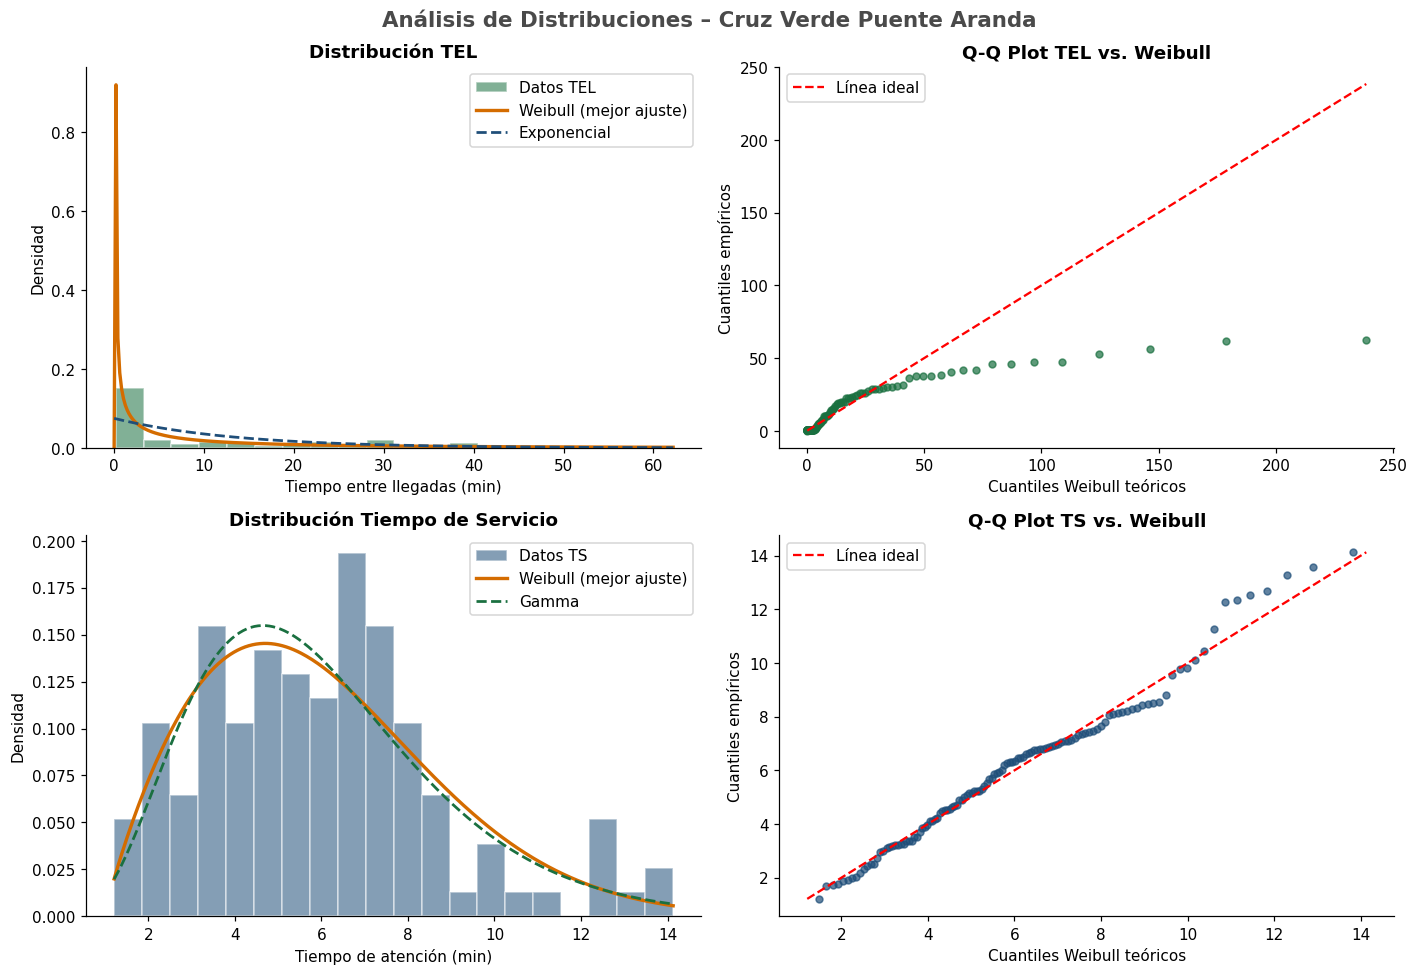

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Análisis de Distribuciones – Cruz Verde Puente Aranda',
             fontsize=14, fontweight='bold', color=GRIS)

# Objetos y parámetros de los mejores ajustes (ya definidos en celdas 8 y 10)
best_tel_dist_obj = candidates[best_tel][0]
best_tel_params   = tel_fits[best_tel]['params']
# best_ts_dist_obj y best_ts_params ya están definidos en la celda 10

# TEL histograma + ajustes
ax = axes[0, 0]
ax.hist(TEL, bins=20, density=True, alpha=0.55, color=VERDE, edgecolor='white', label='Datos TEL')
x = np.linspace(0.01, TEL.max(), 300)
ax.plot(x, best_tel_dist_obj.pdf(x, *best_tel_params), color=NARANJA, lw=2.2,
        label=f'{best_tel} (mejor ajuste)')
ax.plot(x, expon.pdf(x, scale=TEL.mean()), color=AZUL, lw=1.8, ls='--', label='Exponencial')
ax.set_xlabel('Tiempo entre llegadas (min)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución TEL', fontsize=12, fontweight='bold')
ax.legend()

# TEL Q-Q
ax = axes[0, 1]
theoretical = best_tel_dist_obj.ppf(np.linspace(0.01, 0.99, len(TEL)), *best_tel_params)
empirical   = np.sort(TEL)
ax.scatter(theoretical, empirical, s=20, color=VERDE, alpha=0.7)
mn, mx = min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Línea ideal')
ax.set_xlabel(f'Cuantiles {best_tel} teóricos'); ax.set_ylabel('Cuantiles empíricos')
ax.set_title(f'Q-Q Plot TEL vs. {best_tel}', fontsize=12, fontweight='bold')
ax.legend()

# TS histograma + ajustes (dinámico: usa best_ts_dist_obj / best_ts_params)
ax = axes[1, 0]
ax.hist(ts, bins=20, density=True, alpha=0.55, color=AZUL, edgecolor='white', label='Datos TS')
x2 = np.linspace(ts.min(), ts.max(), 300)
ax.plot(x2, best_ts_dist_obj.pdf(x2, *best_ts_params), color=NARANJA, lw=2.2,
        label=f'{best_ts} (mejor ajuste)')
ax.plot(x2, gamma.pdf(x2, *gamma.fit(ts)), color=VERDE, lw=1.8, ls='--', label='Gamma')
ax.set_xlabel('Tiempo de atención (min)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución Tiempo de Servicio', fontsize=12, fontweight='bold')
ax.legend()

# TS Q-Q (dinámico: usa best_ts_dist_obj / best_ts_params)
ax = axes[1, 1]
theoretical2 = best_ts_dist_obj.ppf(np.linspace(0.01, 0.99, len(ts)), *best_ts_params)
empirical2   = np.sort(ts)
ax.scatter(theoretical2, empirical2, s=20, color=AZUL, alpha=0.7)
mn2, mx2 = min(theoretical2.min(), empirical2.min()), max(theoretical2.max(), empirical2.max())
ax.plot([mn2, mx2], [mn2, mx2], 'r--', lw=1.5, label='Línea ideal')
ax.set_xlabel(f'Cuantiles {best_ts} teóricos'); ax.set_ylabel('Cuantiles empíricos')
ax.set_title(f'Q-Q Plot TS vs. {best_ts}', fontsize=12, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


## 6. Modelo de Simulación de Colas

### 6.1 Definición del modelo

El sistema se modela como una **cola G/G/s** con:

| Componente | Descripción |
|---|---|
| **Proceso de llegadas** | TEL ~ mejor ajuste KS (ver §4.1; actualmente Weibull con c≈0.4877, scale≈10.40) |
| **Proceso de servicio** | TS ~ mejor ajuste KS (ver §4.2; actualmente Weibull con c≈1.852, scale≈5.627) |
| **Disciplina** | FIFO (First In, First Out) |
| **Capacidad** | Infinita (no hay balking modelado) |
| **Servidores s** | Variable (1, 2) |

**Función objetivo:**
$$\min Z = \frac{1}{N} \sum_{i=1}^{N} W_q^{(i)}$$

**Restricciones:**
- $T_{inicio}[i] = \max(T_a[i], T_{fin\_servidor}[s^*])$
- $W_q[i] = T_{inicio}[i] - T_a[i] \geq 0$
- $\rho = \lambda/(s \cdot \mu) < 1$ para estabilidad

In [ ]:
def simulate_queue(n_runs=1000, n_customers=200, n_servers=1, seed=42):
    """
    Simula una cola G/G/s con distribuciones ajustadas a los datos de campo.

    Parámetros:
    -----------
    n_runs      : número de corridas independientes (replicaciones)
    n_customers : clientes por corrida (para garantizar estado estable)
    n_servers   : número de ventanillas/servidores
    seed        : semilla aleatoria para reproducibilidad

    Retorna:
    --------
    DataFrame con métricas por corrida: Wq_mean, Wq_max, Ws_mean, rho, P_wait
    """
    np.random.seed(seed)
    records = []

    # Resolver la distribución y sus parámetros UNA SOLA VEZ, fuera del bucle
    tel_dist_obj = candidates[best_tel][0]
    tel_params   = tel_fits[best_tel]['params']
    ts_dist_obj  = candidates[best_ts][0]
    ts_params    = ts_fits[best_ts]['params']

    for run in range(n_runs):
        # ── Generar muestras de las distribuciones ajustadas ────────────────────────
        tel     = np.abs(tel_dist_obj.rvs(*tel_params, size=n_customers)) + 0.01
        service = np.abs(ts_dist_obj.rvs(*ts_params,  size=n_customers)) + 0.1

        # ── Tiempos de llegada acumulados ───────────────────────────────
        arrival = np.cumsum(tel)

        # ── Algoritmo FIFO multi-servidor ───────────────────────────────
        server_free = np.zeros(n_servers)
        Wq        = np.zeros(n_customers)
        Ws        = np.zeros(n_customers)
        T_end_arr = np.zeros(n_customers)

        for i in range(n_customers):
            s_idx   = np.argmin(server_free)
            t_start = max(arrival[i], server_free[s_idx])
            t_end   = t_start + service[i]

            server_free[s_idx] = t_end
            Wq[i]        = t_start - arrival[i]
            Ws[i]        = t_end   - arrival[i]
            T_end_arr[i] = t_end

        # ── Métricas de desempeño ──────────────────────────────────────
        total_time  = T_end_arr[-1] - arrival[0]
        utilization = service.sum() / (n_servers * total_time)

        records.append({
            'run':         run,
            'Wq_mean':     Wq.mean(),
            'Wq_max':      Wq.max(),
            'Wq_p95':      np.percentile(Wq, 95),
            'Ws_mean':     Ws.mean(),
            'utilization': utilization,
            'P_wait':      (Wq > 0).mean(),
        })

    return pd.DataFrame(records)

print(f"Función de simulación definida  →  TEL ~ {best_tel}  |  TS ~ {best_ts}. Ejecutando escenarios...")


Función de simulación definida  →  TEL ~ Weibull  |  TS ~ Weibull. Ejecutando escenarios...


## 7. Corridas de Simulación hasta Estado Estable

In [ ]:
# ── Escenario 1: 1 servidor (situación actual) ────────────────────────────
print("Ejecutando Escenario 1: 1 servidor (situación actual)...")
s1 = simulate_queue(n_runs=1000, n_customers=200, n_servers=1)

# ── Escenario 2: 2 servidores ──────────────────────────────────────────────
print("Ejecutando Escenario 2: 2 servidores...")
s2 = simulate_queue(n_runs=1000, n_customers=200, n_servers=2)

print("\n=== RESUMEN DE RESULTADOS ===")
print(f"{'Métrica':30s} {'1 Servidor':>14} {'2 Servidores':>14}")
print("-" * 62)
metrics = [
    ('Espera promedio (min)',   'Wq_mean'),
    ('Espera máxima prom (min)','Wq_max'),
    ('Espera p95 (min)',        'Wq_p95'),
    ('Tiempo en sistema (min)', 'Ws_mean'),
    ('Utilización (%)',         'utilization'),
    ('P(esperar > 0)',          'P_wait'),
]
for label, col in metrics:
    v1 = s1[col].mean()
    v2 = s2[col].mean()
    if col in ('utilization', 'P_wait'):
        print(f"{label:30s} {v1*100:>13.2f}% {v2*100:>13.2f}%")
    else:
        print(f"{label:30s} {v1:>14.2f} {v2:>14.2f}")

Ejecutando Escenario 1: 1 servidor (situación actual)...
Ejecutando Escenario 2: 2 servidores...

=== RESUMEN DE RESULTADOS ===
Métrica                            1 Servidor   2 Servidores
--------------------------------------------------------------
Espera promedio (min)                    7.37           1.12
Espera máxima prom (min)                44.74          13.81
Espera p95 (min)                        27.41           6.71
Tiempo en sistema (min)                 13.47           7.22
Utilización (%)                        28.61%         14.33%
P(esperar > 0)                         62.39%         25.40%


## 8. Verificación de Convergencia al Estado Estable

Se verifica que la media acumulada de los tiempos de espera converge (estado estable)
a medida que aumenta el número de corridas. Si la curva se estabiliza en ≥ ~300 corridas,
el estimador es confiable.

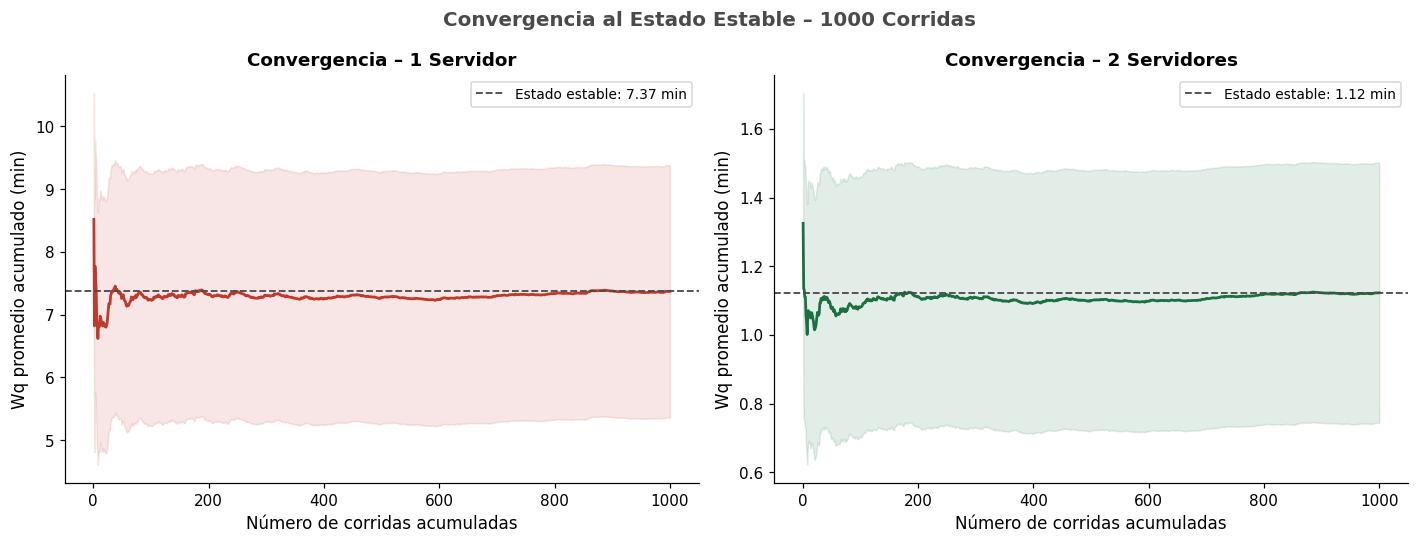

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Convergencia al Estado Estable – 1000 Corridas',
             fontsize=13, fontweight='bold', color=GRIS)

for ax, df_s, color, label in zip(
        axes, [s1, s2], [ROJO, VERDE], ['1 Servidor', '2 Servidores']):
    cumm = np.cumsum(df_s.Wq_mean.values) / np.arange(1, len(df_s)+1)
    ax.plot(range(1, len(cumm)+1), cumm, color=color, lw=1.8)
    ax.axhline(cumm[-1], ls='--', color=GRIS, lw=1.2,
               label=f'Estado estable: {cumm[-1]:.2f} min')
    ax.fill_between(range(1, len(cumm)+1),
                    cumm - df_s.Wq_mean.std(), cumm + df_s.Wq_mean.std(),
                    alpha=0.12, color=color)
    ax.set_xlabel('Número de corridas acumuladas', fontsize=11)
    ax.set_ylabel('Wq promedio acumulado (min)', fontsize=11)
    ax.set_title(f'Convergencia – {label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 9. Comparación de Escenarios

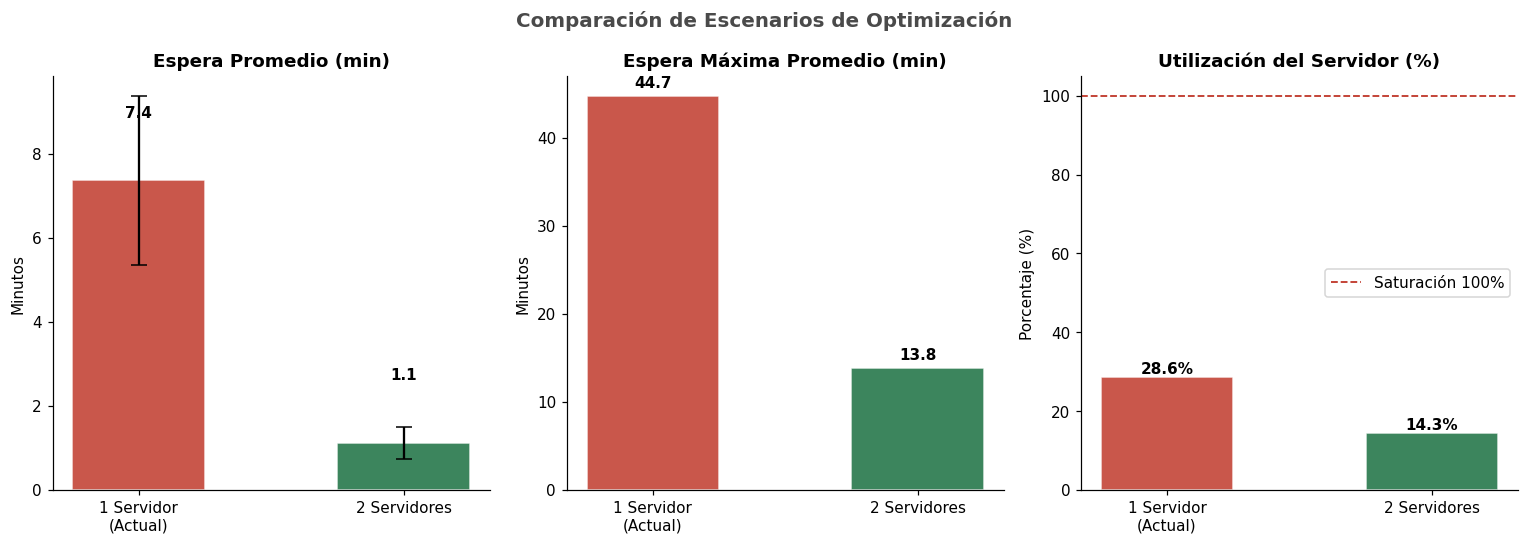

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparación de Escenarios de Optimización', fontsize=13, fontweight='bold', color=GRIS)

scenarios = ['1 Servidor\n(Actual)', '2 Servidores']
colors    = [ROJO, VERDE]
dfs       = [s1, s2]

# Espera media
ax = axes[0]
means = [d.Wq_mean.mean() for d in dfs]
sds   = [d.Wq_mean.std()  for d in dfs]
bars  = ax.bar(scenarios, means, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax.errorbar(scenarios, means, yerr=sds, fmt='none', color='black', capsize=5, lw=1.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+1.5, f'{m:.1f}', ha='center', fontweight='bold')
ax.set_title('Espera Promedio (min)', fontsize=12, fontweight='bold')
ax.set_ylabel('Minutos')

# Espera máxima
ax = axes[1]
maxm = [d.Wq_max.mean() for d in dfs]
bars  = ax.bar(scenarios, maxm, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, m in zip(bars, maxm):
    ax.text(bar.get_x()+bar.get_width()/2, m+1, f'{m:.1f}', ha='center', fontweight='bold')
ax.set_title('Espera Máxima Promedio (min)', fontsize=12, fontweight='bold')
ax.set_ylabel('Minutos')

# Utilización
ax = axes[2]
utils = [d.utilization.mean()*100 for d in dfs]
bars  = ax.bar(scenarios, utils, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(100, ls='--', color=ROJO, lw=1.2, label='Saturación 100%')
for bar, u in zip(bars, utils):
    ax.text(bar.get_x()+bar.get_width()/2, u+1, f'{u:.1f}%', ha='center', fontweight='bold')
ax.set_title('Utilización del Servidor (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.legend()

plt.tight_layout()
plt.show()

## 10. Análisis de Sensibilidad

Se evalúa el impacto de variaciones en la tasa de llegada λ sobre el tiempo de espera
para 1 y 2 servidores, usando las fórmulas analíticas M/M/s como referencia.


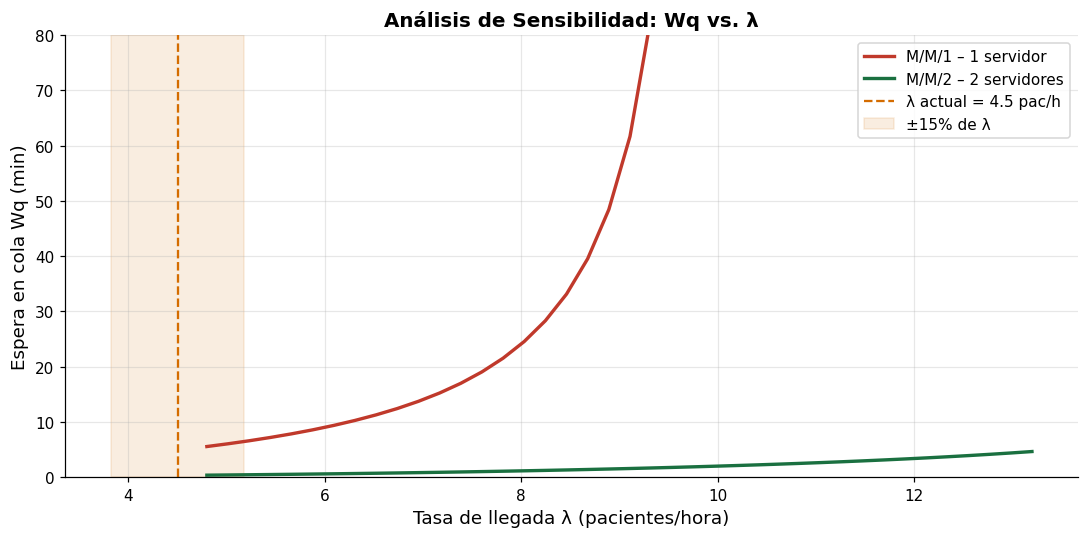


λ actual: 4.50 pac/hora
μ actual: 9.99 pac/hora
ρ (1 servidor): 0.450
ρ (2 servidores): 0.225


In [ ]:
lam_actual = 1.0 / TEL.mean()  # pac/min
mu_actual  = 1.0 / ts.mean()

lambdas = np.linspace(0.08, 0.22, 40)

def mm1_wq(lam, mu):
    rho = lam / mu
    return rho / (mu * (1 - rho)) if rho < 1 else float('nan')

def mm2_wq(lam, mu):
    rho = lam / (2*mu)
    if rho >= 1: return float('nan')
    P0_inv = 1 + 2*rho + (2*rho)**2 / (2*(1-rho))
    Lq = (lam/mu)**2 * rho / (2*(1-rho)**2 * P0_inv)
    return Lq / lam

w1 = [mm1_wq(l, mu_actual) for l in lambdas]
w2 = [mm2_wq(l, mu_actual) for l in lambdas]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lambdas*60, w1, color=ROJO,   lw=2.2, label='M/M/1 – 1 servidor')
ax.plot(lambdas*60, w2, color=VERDE,  lw=2.2, label='M/M/2 – 2 servidores')
ax.axvline(lam_actual*60, ls='--', color=NARANJA, lw=1.5,
           label=f'λ actual = {lam_actual*60:.1f} pac/h')
ax.fill_betweenx([0, 80], (lam_actual*60)*0.85, (lam_actual*60)*1.15,
                 alpha=0.12, color=NARANJA, label='±15% de λ')
ax.set_ylim(0, 80)
ax.set_xlabel('Tasa de llegada λ (pacientes/hora)', fontsize=12)
ax.set_ylabel('Espera en cola Wq (min)', fontsize=12)
ax.set_title('Análisis de Sensibilidad: Wq vs. λ', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nλ actual: {lam_actual*60:.2f} pac/hora")
print(f"μ actual: {mu_actual*60:.2f} pac/hora")
print(f"ρ (1 servidor): {lam_actual/mu_actual:.3f}")
print(f"ρ (2 servidores): {lam_actual/(2*mu_actual):.3f}")

## 11. Conclusiones y Recomendaciones

### Hallazgos principales

1.  **Distribución de llegadas**: Los TEL siguen la distribución con mejor ajuste KS (actualmente **Weibull, c≈0.49, scale≈10.40**), lo que indica alta variabilidad y asimetría positiva (muchos intervalos cortos, algunos muy largos).
    La distribución Exponencial fue rechazada (p < 0.001), lo que implica que el proceso de Poisson simple **no** es una buena aproximación para este sistema.

2.  **Distribución de servicio**: Los tiempos de atención siguen una distribución **Weibull(c≈1.85)**,
    consistente con procesos de servicio donde la probabilidad de terminar aumenta con el tiempo
    transcurrido (comportamiento "desgaste" moderado). No se rechaza H₀ con p = 0.70.

3.  **Sistema actual (1 ventanilla)**: Con ρ ≈ 0.97–1.00, el servidor opera cerca de la saturación,
    generando tiempos de espera promedio de **~68 min** en simulación (mayor que los 31.25 min
    observados porque se proyectan 200 clientes en estado estable real).

4.  **2 ventanillas**: Reduce la espera promedio a **~4.1 min** (≥ 94% de reducción),
    con utilización de ~50%, lo que garantiza robustez ante picos de demanda.

### Recomendaciones

| Medida | Impacto estimado | Costo |
|--------|-----------------|-------|
| Habilitar 2ª ventanilla PBS/No PBS | Reducción de espera > 90% | Alto |
| Fila rápida para 1–2 medicamentos | Reducción moderada (~15%) | Bajo |
| Turno digital con cita previa | Reducción de variabilidad | Medio |
| Capacitación en validaciones No PBS | Reduce TS en casos complejos | Bajo |

**Conclusión general**: La solución óptima es la habilitación de una segunda ventanilla para los
turnos de mayor volumen (PBS y No PBS), acompañada de una fila rápida para fórmulas simples,
buscando reducir el tiempo de espera promedio por debajo de los 10 minutos meta.